# EDA — Dataset Analysis for Multi-Class Vehicle Detection

This notebook performs exploratory data analysis on YOLO-format labels and images to uncover:
- Bounding box aspect ratio distribution
- Bounding box size distribution (relative area; small/medium/large)
- Per-class co-occurrence heatmap
- Image resolution histogram
- Label sanity checks (empty files, out-of-bounds boxes)
- Class imbalance visualization

Edit the `splits` paths below if your dataset layout differs, then run the cells from top to bottom.

In [1]:
# Imports
import os
from pathlib import Path
import glob
import collections
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

sns.set(style="whitegrid")

In [2]:
# Dataset splits - adjust paths if needed
splits = {
    'train': {'images': Path('data/train/images'), 'labels': Path('data/train/labels')},
    'val': {'images': Path('data/val/images'), 'labels': Path('data/val/labels')},
    'test': {'images': Path('data/test/images'), 'labels': Path('data/test/labels')},
}

def parse_yolo_label(path):
    # returns list of dicts: {'cls':int, 'x':float,'y':float,'w':float,'h':float} with normalized coords
    out = []
    try:
        with open(path, 'r', encoding='utf-8') as f:
            for ln in f:
                ln = ln.strip()
                if not ln:
                    continue
                parts = ln.split()
                if len(parts) < 5:
                    continue
                try:
                    cls = int(float(parts[0]))
                    x,y,w,h = map(float, parts[1:5])
                except Exception:
                    continue
                out.append({'cls':cls,'x':x,'y':y,'w':w,'h':h})
    except FileNotFoundError:
        pass
    return out

def bbox_absolute_metrics(box, img_w, img_h):
    # box: dict with normalized x,y,w,h center format
    w_px = box['w'] * img_w
    h_px = box['h'] * img_h
    area_px = w_px * h_px
    rel_area = area_px / (img_w * img_h) if img_w*img_h>0 else 0
    aspect = (w_px / h_px) if h_px>0 else float('nan')
    # corners in normalized coords
    x_min = box['x'] - box['w']/2
    x_max = box['x'] + box['w']/2
    y_min = box['y'] - box['h']/2
    y_max = box['y'] + box['h']/2
    oob = x_min < 0 or y_min < 0 or x_max > 1 or y_max > 1
    non_positive = box['w'] <= 0 or box['h'] <= 0
    return {'w_px':w_px,'h_px':h_px,'area_px':area_px,'rel_area':rel_area,'aspect':aspect,'oob':oob,'non_positive':non_positive}

In [3]:
# Aggregate dataset-wide metrics
rows = []
image_stats = []
class_counts = collections.Counter()
cooccurrence = collections.defaultdict(lambda: collections.Counter())
empty_label_files = []
oob_labels = []
non_positive_labels = []
resolution_counts = collections.Counter()

for split, paths in splits.items():
    images_dir = paths['images']
    labels_dir = paths['labels']
    if not images_dir.exists():
        continue
    image_files = list(images_dir.glob('*'))
    for img_path in tqdm(image_files, desc=f'Processing {split}'):
        try:
            with Image.open(img_path) as im:
                img_w, img_h = im.size
        except Exception:
            continue
        resolution_counts[(img_w, img_h)] += 1
        lbl_path = labels_dir / (img_path.stem + '.txt')
        items = parse_yolo_label(lbl_path)
        if not items:
            empty_label_files.append(str(lbl_path))
        classes_in_image = set()
        for b in items:
            metrics = bbox_absolute_metrics(b, img_w, img_h)
            row = {'split':split,'image':str(img_path),'class':b['cls'],'x':b['x'],'y':b['y'],'w':b['w'],'h':b['h'],'img_w':img_w,'img_h':img_h}
            row.update(metrics)
            rows.append(row)
            class_counts[b['cls']] += 1
            if metrics['oob']:
                oob_labels.append({'file':str(lbl_path),'box':b,'metrics':metrics})
            if metrics['non_positive']:
                non_positive_labels.append({'file':str(lbl_path),'box':b,'metrics':metrics})
            classes_in_image.add(b['cls'])
        # update cooccurrence (pairs)
        for a in classes_in_image:
            for bcls in classes_in_image:
                if a == bcls:
                    continue
                cooccurrence[a][bcls] += 1
        image_stats.append({'image':str(img_path),'img_w':img_w,'img_h':img_h,'n_boxes':len(items),'split':split})

df_boxes = pd.DataFrame(rows)
df_images = pd.DataFrame(image_stats)

print('Total boxes:', len(df_boxes))
print('Total images scanned:', len(df_images))
print('Unique resolutions:', len(resolution_counts))
print('Empty label files:', len(empty_label_files))
print('Out-of-bounds labels:', len(oob_labels))
print('Non-positive boxes:', len(non_positive_labels))

Processing test: 100%|██████████| 982/982 [00:00<00:00, 6335.28it/s]


Total boxes: 83888
Total images scanned: 9816
Unique resolutions: 1
Empty label files: 984
Out-of-bounds labels: 199
Non-positive boxes: 0


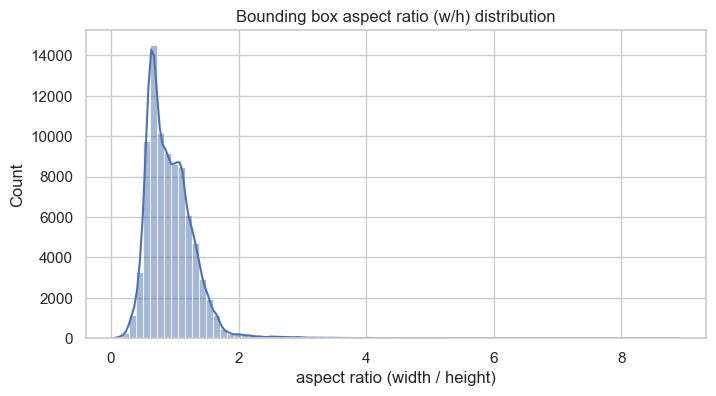

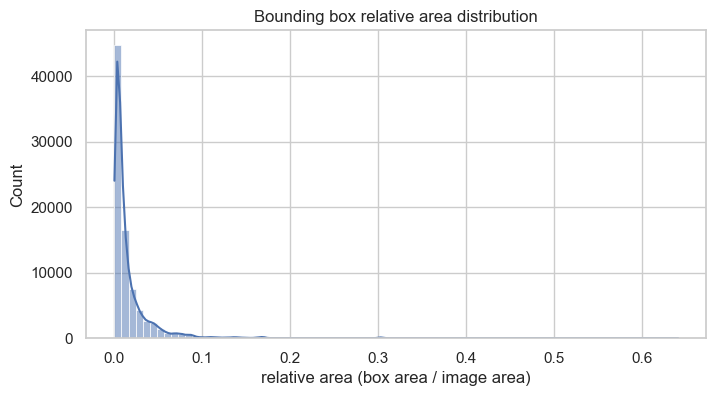

,small_threshold,large_threshold,median_rel_area
0,0.00188,0.038912,0.007385


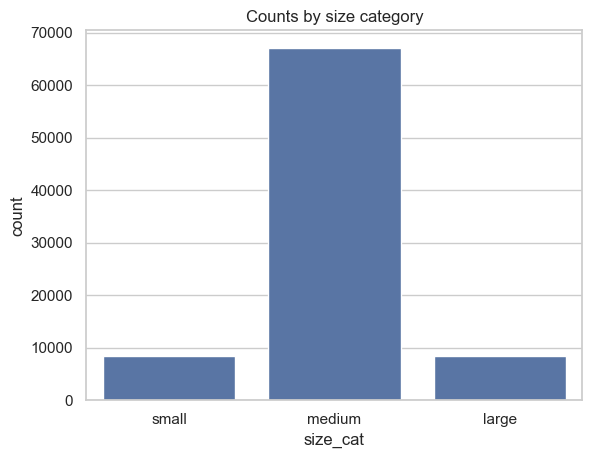

In [4]:
# Aspect ratio distribution (w/h)
if not df_boxes.empty:
    plt.figure(figsize=(8,4))
    sns.histplot(df_boxes['aspect'].replace([np.inf,-np.inf],np.nan).dropna(), bins=80, kde=True)
    plt.title('Bounding box aspect ratio (w/h) distribution')
    plt.xlabel('aspect ratio (width / height)')
    plt.show()

# Size distribution (relative area) and simple small/medium/large categories
    plt.figure(figsize=(8,4))
    sns.histplot(df_boxes['rel_area'].dropna(), bins=80, kde=True)
    plt.title('Bounding box relative area distribution')
    plt.xlabel('relative area (box area / image area)')
    plt.show()

    # define thresholds by percentiles (you can change these)
    p10, p50, p90 = np.percentile(df_boxes['rel_area'].dropna(), [10,50,90])
    small_th = p10
    large_th = p90
    def size_label(a):
        if a <= small_th:
            return 'small'
        if a >= large_th:
            return 'large'
        return 'medium'
    df_boxes['size_cat'] = df_boxes['rel_area'].map(size_label)
    display(pd.DataFrame({
        'small_threshold':small_th, 'large_threshold':large_th, 'median_rel_area':p50
    }, index=[0]))
    sns.countplot(data=df_boxes, x='size_cat', order=['small','medium','large'])
    plt.title('Counts by size category')
    plt.show()

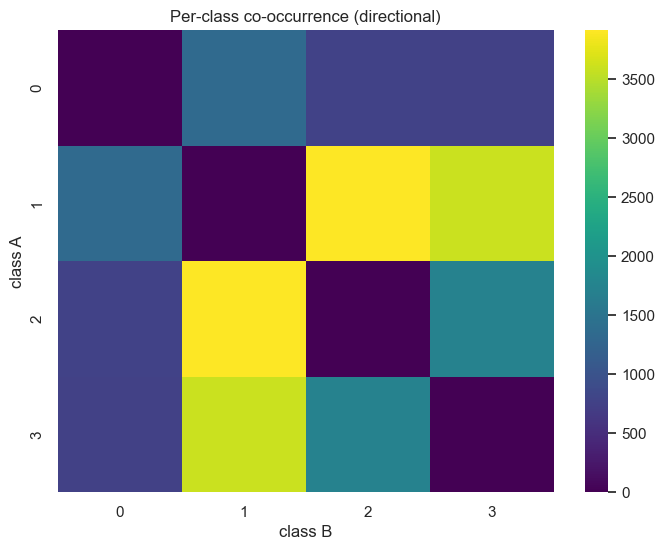

In [5]:
# Per-class co-occurrence heatmap
if len(class_counts) > 0:
    classes = sorted(class_counts.keys())
    mat = np.zeros((len(classes), len(classes)), dtype=int)
    idx = {c:i for i,c in enumerate(classes)}
    for a in classes:
        for bcls, cnt in cooccurrence[a].items():
            mat[idx[a], idx[bcls]] = cnt
    df_co = pd.DataFrame(mat, index=classes, columns=classes)
    plt.figure(figsize=(8,6))
    sns.heatmap(df_co, cmap='viridis')
    plt.title('Per-class co-occurrence (directional)')
    plt.xlabel('class B')
    plt.ylabel('class A')
    plt.show()

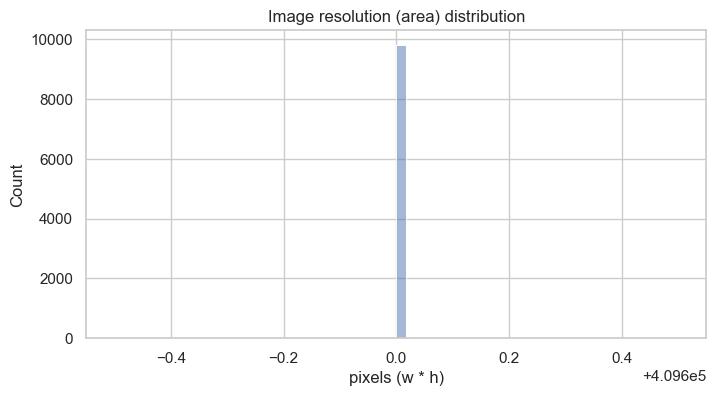

,img_w,img_h
0,640,640


In [6]:
# Image resolution histogram
if not df_images.empty:
    df_images['area'] = df_images['img_w'] * df_images['img_h']
    plt.figure(figsize=(8,4))
    sns.histplot(df_images['area'], bins=60, kde=True)
    plt.title('Image resolution (area) distribution')
    plt.xlabel('pixels (w * h)')
    plt.show()
    display(df_images[['img_w','img_h']].drop_duplicates().head(20))

In [8]:
# Label sanity checks: show examples
print('Empty label files (examples):')
for p in empty_label_files[:20]:
    print(' ', p)

print('Out-of-bounds examples:')
for e in oob_labels[:20]:
    print(' ', e['file'], 'box=', e['box'], 'metrics=', {k:e['metrics'][k] for k in ('oob',)})

print('Non-positive box examples:')
for e in non_positive_labels[:20]:
    print(' ', e['file'], 'box=', e['box'], 'metrics=', {k:e['metrics'][k] for k in ('non_positive',)})

Empty label files (examples):
  data/val/labels/MVI_40172_img02570_jpg.rf.3a486438eecb4812275bd2958a8b10c4.txt
  data/val/labels/MVI_40172_img00696_jpg.rf.71ed1f8014b8b30d31b3650a5593c833.txt
  data/test/labels/MVI_40192_img00406_jpg.rf.b04c81c38fde88565db50d0b63963523.txt
  data/test/labels/MVI_40991_img00061_jpg.rf.ef06d1379feb16556c562344e0b4c7fb.txt
  data/test/labels/MVI_20062_img00230_jpg.rf.d8b5505b8d2b42a24619e1d6c678e6b6.txt
  data/test/labels/MVI_41063_img01454_jpg.rf.aa4ef5bc097188835ce0240a9dd991a6.txt
  data/test/labels/MVI_39781_img01465_jpg.rf.72626da7f741b98368f7d0faf080471c.txt
  data/test/labels/MVI_40192_img01485_jpg.rf.1e430f61249c61393135e34b3804657b.txt
  data/test/labels/MVI_40855_img00478_jpg.rf.44ac784537bae78b28bb96192b9a243d.txt
  data/test/labels/MVI_40131_img00672_jpg.rf.14540972137fc32f6914ede8d338c12f.txt
  data/test/labels/MVI_40905_img01629_jpg.rf.2d5c4bbde79cb43fd35479ef8fd7c6fa.txt
  data/test/labels/MVI_40871_img00882_jpg.rf.5d781f2d6e7efcf1374ef4e29

,class,count
0,0,1433
1,1,68855
2,2,6512
3,3,7088


/var/folders/v6/frwp0yjs06j_wm3461r0j6rr0000gp/T/ipykernel_8687/4059000730.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cls_df, x='class', y='count', palette='muted')


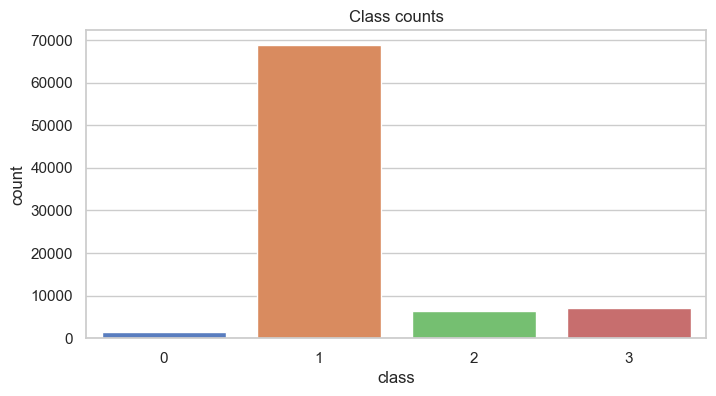

Top classes by count:
   1 68855
   3 7088
   2 6512
   0 1433


In [9]:
# Class imbalance visualization and counts
if len(class_counts)>0:
    cls_df = pd.DataFrame(sorted(class_counts.items(), key=lambda x: x[0]), columns=['class','count'])
    display(cls_df)
    plt.figure(figsize=(8,4))
    sns.barplot(data=cls_df, x='class', y='count', palette='muted')
    plt.title('Class counts')
    plt.show()
    print('Top classes by count:')
    for c,n in cls_df.sort_values('count', ascending=False).head(10).values:
        print('  ', c, n)

## Notes and next steps
- Thresholds for small/medium/large are percentile-based; adjust `small_th` and `large_th` if you prefer absolute cutoffs.
- If labels use different coordinate formats, update `parse_yolo_label`.
- I can run these cells here if you want me to execute them and present the resulting plots and tables — tell me to run the notebook or run it locally in your environment.